## Project: Concept Bottleneck Models on CelebA (Smiling)
In this project, you will study Concept Bottleneck Models (CBMs) and their variants on a real vision dataset. Using CelebA and Smiling as the prediction target, you will compare:

a standard image classifier (x → y)
a concept bottleneck model (x → c → y)
a hybrid CBM with a direct side channel (x → y) under varying side-channel dropout
You will analyze the tradeoff between accuracy, interpretability, and steerability.



Dataset
Use the CelebA dataset provided by torchvision.datasets.CelebA.

Inputs (x): RGB face images
Label (y): Smiling
Concepts (c): the following fixed subset of CelebA attributes (binary):
C_sub (10 concepts):

Mouth_Slightly_Open
High_Cheekbones
Chubby
Narrow_Eyes
Bags_Under_Eyes
Big_Lips
Big_Nose
Pointy_Nose
Bushy_Eyebrows
Arched_Eyebrows
Important: Do not include Smiling as a concept.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("collinmartin009/celeba-zip")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [00:12<00:00, 117MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/collinmartin009/celeba-zip/versions/1


In [6]:
import os
print(os.listdir(path))

['celeba']


In [ ]:
%pip install pytorch-lightning;
%pip install torchmetrics;
%pip install torchvision;
%pip install torch;
%pip install matplotlib;
%pip install numpy;
%pip install pandas;
%pip install seaborn;

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.5 MB/s eta 0:00:00


In [ ]:
# from pathlib import Path
# from google.colab import drive
# drive.mount("/content/drive")

In [9]:
# CELEBA_ROOT = Path("/content/drive/MyDrive")
CELEBA_ROOT = path# Use with colab gpu

In [10]:
import os
import time
import pathlib


image_folder_path = pathlib.Path(CELEBA_ROOT) / "celeba" / "img_align_celeba"

# Retry mechanism for Google Drive access issues
max_retries = 3
retries = 0
num_files = 0
directory_accessible = False

while retries < max_retries:
    try:
        if image_folder_path.exists() and image_folder_path.is_dir():
            num_files = len([f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))])
            directory_accessible = True
            break
        else:
            print(f"Attempt {retries + 1}/{max_retries}: The directory {image_folder_path} does not exist or is not a directory.")
            break # Exit if the path itself is invalid, retrying won't help
    except OSError as e:
        retries += 1
        print(f"Attempt {retries}/{max_retries}: Failed to access directory. Error: {e}. Retrying in 5 seconds...")
        time.sleep(5)

if directory_accessible:
    print(f"Number of files in {image_folder_path}: {num_files}")
else:
    print(f"Could not access the directory {image_folder_path} after {max_retries} attempts.")

Number of files in /root/.cache/kagglehub/datasets/collinmartin009/celeba-zip/versions/1/celeba/img_align_celeba: 202599


- Use the official CelebA train/val/test split provided by torchvision
Resize images to a fixed resolution (e.g., 128×128)

- Normalize images using ImageNet statistics

Normalizing images before passing them into a pretrained model like ResNet is a preprocessing step that ensures your input data matches the distribution the model was originally trained on.
The process has two steps. First, scale raw pixel values from their original range of 0-255 down to 0-1 by dividing by 255. Second, normalize each channel using the ImageNet mean [0.485, 0.456, 0.406] and standard deviation [0.229, 0.224, 0.225], where each value corresponds to the R, G, and B channels respectively. The formula applied per channel is (x - mean) / std.
The reason you use ImageNet statistics specifically is that ResNet's weights were learned assuming inputs with that distribution. If you feed in data that looks statistically different, the activations throughout the network will be off, and the pretrained weights become less useful. In PyTorch this is handled cleanly with transforms.Normalize

In [11]:
import os
import torch
from torchvision.datasets import CelebA
from torch.utils.data import Subset
from torchvision import transforms

# 1. Setup Transforms (from your document)
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Initialize the standard datasets (These contain the "Maps" of all 200k+ files)
# Note: We assign them to distinct variables for clarity
dataset = CelebA(root=CELEBA_ROOT, split="train", target_type="attr", transform=transform, download=False)
val_dataset = CelebA(root=CELEBA_ROOT, split="valid", target_type="attr", transform=transform, download=False)
test_dataset = CelebA(root=CELEBA_ROOT, split="test", target_type="attr", transform=transform, download=False)


print("--- Validation Complete ---")
print(f"Final Train Size: {len(dataset)}")
print(f"Final Valid Size: {len(val_dataset)}")
print(f"Final Test Size:  {len(test_dataset)}")

--- Validation Complete ---
Final Train Size: 162770
Final Valid Size: 19867
Final Test Size:  19962


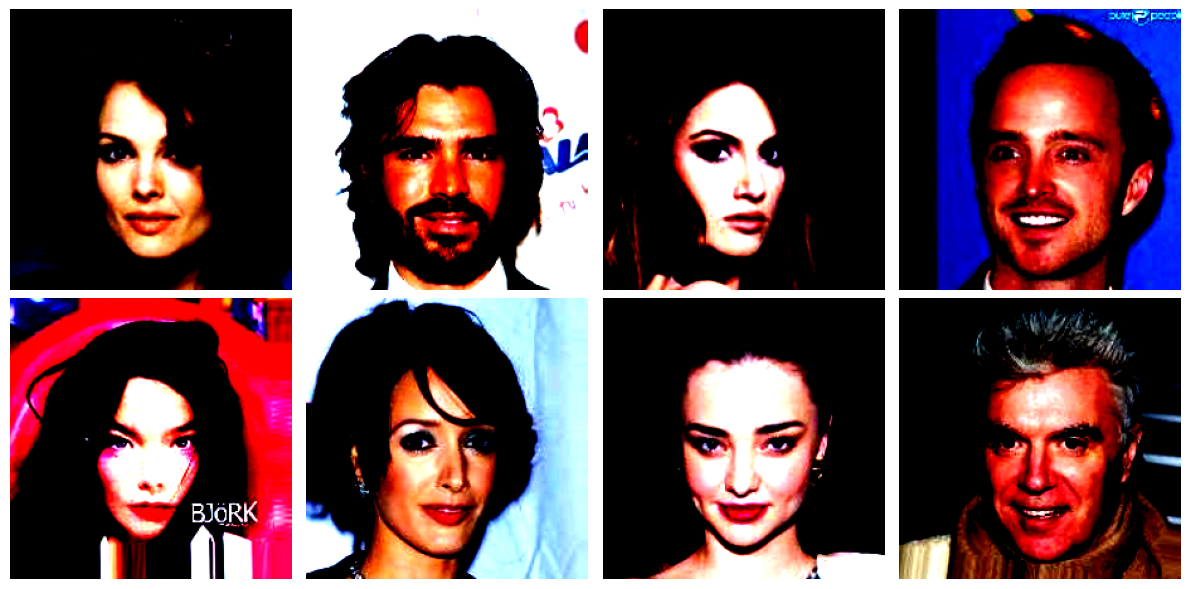

In [12]:
import matplotlib.pyplot as plt

def show_batch(dataset, num=8, figsize=(12, 6)):
    fig, axs = plt.subplots(2, 4, figsize=figsize)
    axs = axs.flatten()
    for i in range(min(num, len(dataset))):
        img, _ = dataset[i]
        if img.dim() == 3:
            img = img.permute(1, 2, 0)
        axs[i].imshow(img.clamp(0, 1))
        axs[i].axis("off")
    plt.tight_layout()
    plt.show()

show_batch(val_dataset, num=8)

In [ ]:
print(dataset.attr_names)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young', '']


Report class balance for Smiling and each concept

['Smiling', 'Mouth_Slightly_Open', 'High_Cheekbones', 'Chubby', 'Narrow_Eyes', 'Bags_Under_Eyes', 'Big_Lips', 'Big_Nose', 'Pointy_Nose', 'Bushy_Eyebrows', 'Arched_Eyebrows'] 

Smiling                    47.97% positive
Mouth_Slightly_Open        48.22% positive
High_Cheekbones            45.24% positive
Chubby                     5.77% positive
Narrow_Eyes                11.59% positive
Bags_Under_Eyes            20.45% positive
Big_Lips                   24.09% positive
Big_Nose                   23.56% positive
Pointy_Nose                27.55% positive
Bushy_Eyebrows             14.37% positive
Arched_Eyebrows            26.59% positive


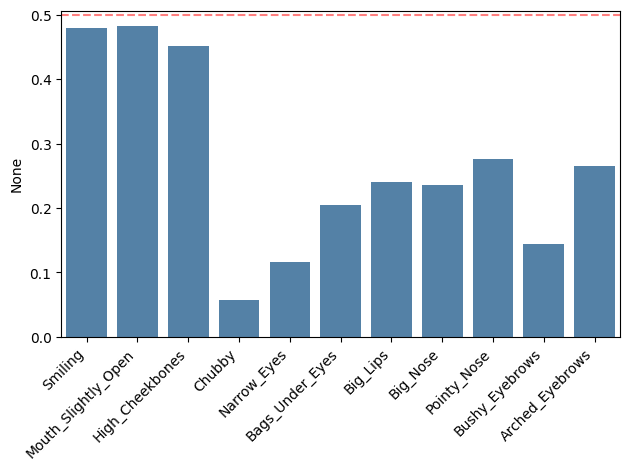

In [13]:
import seaborn as sns

LABEL_NAME = 'Smiling'
CONCEPT_NAMES = ["Mouth_Slightly_Open", "High_Cheekbones",
                 "Chubby", "Narrow_Eyes", "Bags_Under_Eyes",
                 "Big_Lips", "Big_Nose", "Pointy_Nose",
                 "Bushy_Eyebrows", "Arched_Eyebrows"]

names = [LABEL_NAME] + CONCEPT_NAMES
print(names, "\n")
attr_names = list(dataset.attr_names)
idxs = [attr_names.index(n) for n in names]

props = dataset.attr[:, idxs].float().mean(dim=0)

for n, p in zip(names, props):
    print(f"{n:25s}  {p:.2%} positive")
    sns.barplot(x=names, y=props, color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Model architecture
Use ResNet-18, available directly from torchvision.models.

Initialize with ImageNet pretrained weights
Remove the final classification layer
Use the shared backbone for all model variants
ResNet-18 is chosen because it is:

- lightweight (~11M parameters)
- well-understood and stable
- fast enough for repeated experiments (dropout sweeps)

#### Why reuse it rather than train from scratch?
ResNet-18 already knows how to detect edges, corners, textures, object parts. These low-level and mid-level features transfer well across vision tasks. Training that from scratch on your own dataset would require a lot more data and compute. You're essentially borrowing 1.2M images worth of learning for free.
#### Why remove the last layer?
The final fc layer is specific to ImageNet's 1000 classes. It's useless for your task. You want the 512-feature representation that precedes it, and then you'll attach your own task-specific head on top — whether that's a different number of output classes, a regression output, or in your case, variants with different dropout configurations.

In [18]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torch import nn


resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

backbone = nn.Sequential(*list(resnet.children())[:-1])


x = torch.randn(8, 3, 224, 224)
with torch.no_grad():
    out = backbone(x)

print(out.shape)

torch.Size([8, 512, 1, 1])


### 1) Baseline classifier (x → y)

**A standard image classifier: (x → y)**

- ResNet-18 backbone
- Single linear classification head

Report:

- Test Accuracy
- Test AUROC

In [19]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses, title=""):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [20]:
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

SMILING_IDX = dataset.attr_names.index('Smiling')  # should be 31

class BaselineClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # strip fc
        self.classifier = nn.Linear(512, 1)  # single binary output

    def forward(self, x):
        features = self.backbone(x)
        features = features.flatten(start_dim=1)  # (B, 512)
        return self.classifier(features)           # (B, 1)


def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            smiling_labels = labels[:, SMILING_IDX].float()  # extract Smiling only

            logits = model(images).squeeze(1)  # (B,)
            probs = torch.sigmoid(logits)

            all_labels.append(smiling_labels.numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    preds = (all_probs >= 0.5).astype(int)
    accuracy = (preds == all_labels).mean()
    auroc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test AUROC:    {auroc:.4f}")
    return accuracy, auroc

In [21]:
dataset.file_list

[('0B7EVK8r0v71pZjFTYXZWM3FlRnM',
  '00d2c5bc6d35e252742224ab0c1e8fcb',
  'img_align_celeba.zip'),
 ('0B7EVK8r0v71pblRyaVFSWGxPY0U',
  '75e246fa4810816ffd6ee81facbd244c',
  'list_attr_celeba.txt'),
 ('1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS',
  '32bd1bd63d3c78cd57e08160ec5ed1e2',
  'identity_CelebA.txt'),
 ('0B7EVK8r0v71pbThiMVRxWXZ4dU0',
  '00566efa6fedff7a56946cd1c10f1c16',
  'list_bbox_celeba.txt'),
 ('0B7EVK8r0v71pd0FJY3Blby1HUTQ',
  'cc24ecafdb5b50baae59b03474781f8c',
  'list_landmarks_align_celeba.txt'),
 ('0B7EVK8r0v71pY0NSMzRuSXJEVkk',
  'd32c9cbf5e040fd4025c592c306e6668',
  'list_eval_partition.txt')]

### Train the Baseline Classifier (x → y)
- Create training loop for the baseline model
- Implement loss function (Binary Cross Entropy)
- Add optimizer (Adam or SGD)
- Train for several epochs and save the best model
- Evaluate on test set properly

Epoch 1/1 | Loss: 0.1889 | Val Loss: 0.1681 | Val AUROC: 0.9825
  --> New best model saved (AUROC: 0.9825)

Training complete. Best Val AUROC: 0.9824552656011245

=== TEST SET RESULTS ===
Test Accuracy: 0.9268
Test AUROC:    0.9812
Baseline (x→y)                0.9268     0.9812
Model saved to baseline_classifier.pth


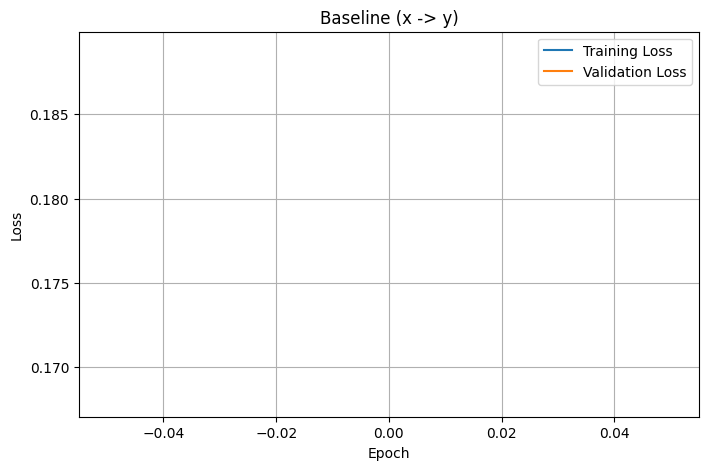

In [23]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(dataset,     batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

def train_baseline(model, train_loader, val_loader, device, num_epochs=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_auroc = 0.0
    best_weights = None
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            targets = labels[:, SMILING_IDX].float().to(device)  # (B,)

            optimizer.zero_grad()
            logits = model(images).squeeze(1)   # (B,)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        all_labels, all_probs = [], []
        val_total_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                targets = labels[:, SMILING_IDX].float().to(device)

                logits = model(images).squeeze(1)
                loss = criterion(logits, targets)
                val_total_loss += loss.item()

                probs = torch.sigmoid(logits).cpu().numpy()
                all_labels.append(targets.cpu().numpy())
                all_probs.append(probs)

        avg_val_loss = val_total_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_labels = np.concatenate(all_labels)
        all_probs  = np.concatenate(all_probs)
        val_auroc  = roc_auc_score(all_labels, all_probs)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUROC: {val_auroc:.4f}")

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  --> New best model saved (AUROC: {best_val_auroc:.4f})")

    # Restore best weights
    model.load_state_dict(best_weights)
    print("\nTraining complete. Best Val AUROC:", best_val_auroc)
    return model, train_losses, val_losses

model = BaselineClassifier().to(device)
model, baseline_train_losses, baseline_val_losses = train_baseline(model, train_loader, val_loader, device, num_epochs=1)

print("\n=== TEST SET RESULTS ===")
baseline_acc, baseline_auroc = evaluate(model, test_loader, device)
print(f"{'Baseline (x→y)':<25} {baseline_acc:>10.4f} {baseline_auroc:>10.4f}")

torch.save(model.state_dict(), "baseline_classifier.pth")
print("Model saved to baseline_classifier.pth")

plot_loss_curves(baseline_train_losses, baseline_val_losses, title="Baseline (x -> y)")

### 2) Concept predictor (x → c)
A multi-label model that predicts the predefined concept vector from the input image.

- Shared backbone as above
- One binary prediction head per concept (or an equivalent multi-output head)
- Binary cross-entropy loss (use class weighting if appropriate)

### Report:

- Per-concept performance (accuracy or F1 score)
- Mean concept performance (macro-average)


In [24]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

CONCEPT_IDXS = [list(dataset.attr_names).index(n) for n in CONCEPT_NAMES]
NUM_CONCEPTS = len(CONCEPT_NAMES)

class ConceptPredictor(nn.Module):
    def __init__(self, num_concepts=NUM_CONCEPTS):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Linear(512, num_concepts)

    def forward(self, x):
        features = self.backbone(x).flatten(start_dim=1)  # (B, 512)
        return self.head(features)

In [25]:
import torch

# Shape: (N, 10) — concept labels for all training samples
concept_labels = dataset.attr[:, CONCEPT_IDXS].float()

pos_counts = concept_labels.sum(dim=0)          # (10,)
neg_counts  = len(concept_labels) - pos_counts  # (10,)
pos_weight  = neg_counts / pos_counts.clamp(min=1)  # (10,) — ratio of neg:pos

print("pos_weight per concept:")
for name, w in zip(CONCEPT_NAMES, pos_weight):
    print(f"  {name:25s}  {w:.2f}")

pos_weight per concept:
  Mouth_Slightly_Open        1.07
  High_Cheekbones            1.21
  Chubby                     16.34
  Narrow_Eyes                7.63
  Bags_Under_Eyes            3.89
  Big_Lips                   3.15
  Big_Nose                   3.25
  Pointy_Nose                2.63
  Bushy_Eyebrows             5.96
  Arched_Eyebrows            2.76


In [26]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(dataset,     batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

Epoch 1/1 | Loss: 0.6280 | Val Loss: 0.5943 | Val Macro-F1: 0.6345
  --> New best model saved (Macro-F1: 0.6345)

Training complete. Best Val Macro-F1: 0.6344995115227368


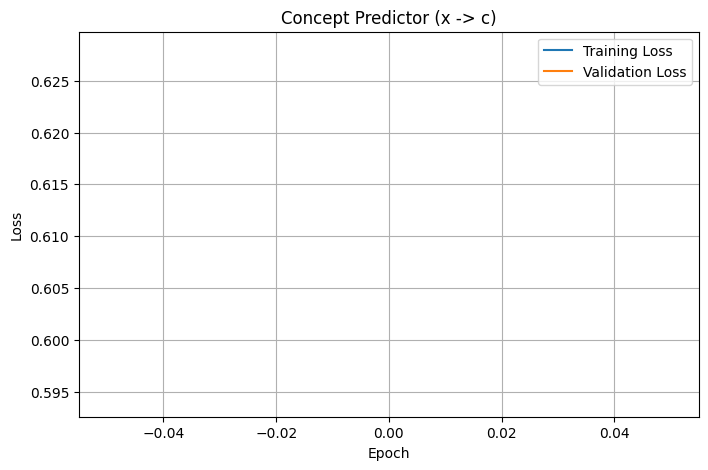

In [27]:
from sklearn.metrics import f1_score
import numpy as np

def train_concept_predictor(model, train_loader, val_loader, device, pos_weight, num_epochs=5):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight.to(device)  # broadcast across batch
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val_f1 = 0.0
    best_weights = None
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images  = images.to(device)
            targets = labels[:, CONCEPT_IDXS].float().to(device)  # (B, 10)

            optimizer.zero_grad()
            logits = model(images)           # (B, 10)
            loss   = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        all_labels, all_preds = [], []
        val_total_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(device)
                targets = labels[:, CONCEPT_IDXS].float().to(device)

                logits  = model(images)
                loss    = criterion(logits, targets)
                val_total_loss += loss.item()

                preds   = (torch.sigmoid(logits) >= 0.5).int().cpu()
                all_labels.append(targets.cpu().numpy())
                all_preds.append(preds.numpy())

        avg_val_loss = val_total_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_labels = np.concatenate(all_labels)  # (N, 10)
        all_preds  = np.concatenate(all_preds)

        # Macro-averaged F1 across concepts
        macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Macro-F1: {macro_f1:.4f}")

        if macro_f1 > best_val_f1:
            best_val_f1    = macro_f1
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  --> New best model saved (Macro-F1: {best_val_f1:.4f})")

    model.load_state_dict(best_weights)
    print("\nTraining complete. Best Val Macro-F1:", best_val_f1)
    return model, train_losses, val_losses

concept_model = ConceptPredictor().to(device)
concept_model, concept_train_losses, concept_val_losses = train_concept_predictor(
    concept_model, train_loader, val_loader, device, pos_weight, num_epochs=1
)

plot_loss_curves(concept_train_losses, concept_val_losses, title="Concept Predictor (x -> c)")

In [28]:
def evaluate_concepts(model, dataloader, device):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images  = images.to(device)
            targets = labels[:, CONCEPT_IDXS].float()
            logits  = model(images).cpu()
            preds   = (torch.sigmoid(logits) >= 0.5).int()

            all_labels.append(targets.numpy())
            all_preds.append(preds.numpy())

    all_labels = np.concatenate(all_labels)
    all_preds  = np.concatenate(all_preds)

    print(f"{'Concept':<25} {'Accuracy':>10} {'F1':>10}")
    print("-" * 47)

    accs, f1s = [], []
    for i, name in enumerate(CONCEPT_NAMES):
        acc = (all_preds[:, i] == all_labels[:, i]).mean()
        f1  = f1_score(all_labels[:, i], all_preds[:, i], zero_division=0)
        accs.append(acc)
        f1s.append(f1)
        print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")

    print("-" * 47)
    print(f"{'Macro Average':<25} {np.mean(accs):>10.4f} {np.mean(f1s):>10.4f}")

print("\n=== TEST SET CONCEPT PERFORMANCE ===")
evaluate_concepts(concept_model, test_loader, device)

torch.save(concept_model.state_dict(), "concept_predictor.pth")
print("Model saved to concept_predictor.pth")


=== TEST SET CONCEPT PERFORMANCE ===
Concept                     Accuracy         F1
-----------------------------------------------
Mouth_Slightly_Open           0.9360     0.9344
High_Cheekbones               0.8544     0.8569
Chubby                        0.8382     0.3685
Narrow_Eyes                   0.8306     0.5301
Bags_Under_Eyes               0.8468     0.6319
Big_Lips                      0.6184     0.5815
Big_Nose                      0.7912     0.6054
Pointy_Nose                   0.6997     0.5900
Bushy_Eyebrows                0.9221     0.6979
Arched_Eyebrows               0.7916     0.7085
-----------------------------------------------
Macro Average                 0.8129     0.6505
Model saved to concept_predictor.pth


### 3) Concept Bottleneck Model (x → c → y)
A model in which predictions must pass explicitly through the concept representation.

- Concept predictor as defined above
- Label head operating only on predicted concepts (e.g. linear layer or small MLP)
- Training strategy
- Choose one of the following and state it clearly:
    - Independent CBM:
        - Train x → c, freeze it, then train c → y
    - Joint CBM:
        - Train the entire model end-to-end with a combined loss

### Report:

- Test accuracy and AUROC on the target task
- Concept prediction metrics
- Quantitative comparison with the baseline x → y model

In [29]:
class ConceptBottleneckModel(nn.Module):
    def __init__(self, num_concepts=NUM_CONCEPTS):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone     = nn.Sequential(*list(resnet.children())[:-1])
        self.concept_head = nn.Linear(512, num_concepts)  # x → c
        self.label_head   = nn.Linear(num_concepts, 1)    # c → y

    def forward(self, x):
        features       = self.backbone(x).flatten(start_dim=1)  # (B, 512)
        concept_logits = self.concept_head(features)             # (B, 10)
        concept_probs  = torch.sigmoid(concept_logits)           # (B, 10) — keep interpretable
        label_logit    = self.label_head(concept_probs)          # (B, 1)
        return concept_logits, label_logit

# Load pretrained concept predictor weights
cbm_model = ConceptBottleneckModel().to(device)
cbm_model.backbone.load_state_dict(concept_model.backbone.state_dict())
cbm_model.concept_head.load_state_dict(concept_model.head.state_dict())  # note: .head not .concept_head

# Freeze backbone and concept head
for param in cbm_model.backbone.parameters():
    param.requires_grad = False
for param in cbm_model.concept_head.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in cbm_model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable}")  # should be 11 (10 weights + 1 bias)

Trainable parameters: 11


Epoch 1/1 | Loss: 0.4480 | Val Loss: 0.3560 | Val AUROC: 0.9441
  --> New best saved (AUROC: 0.9441)

Training complete. Best Val AUROC: 0.9441057751708449


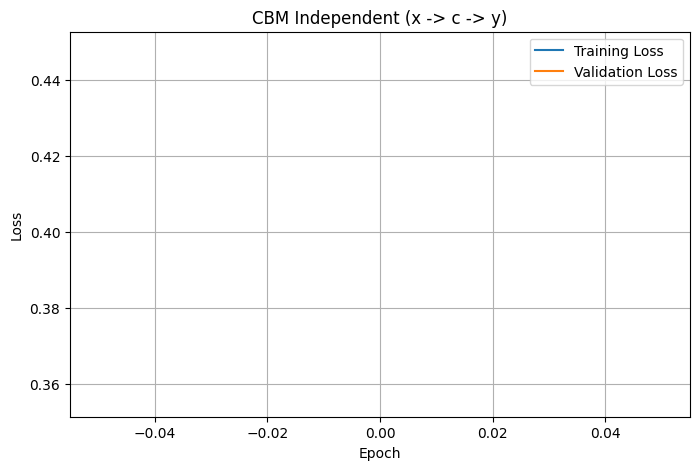

In [31]:
def train_cbm_independent(model, train_loader, val_loader, device, num_epochs=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
    )

    best_val_auroc = 0.0
    best_weights   = None
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images   = images.to(device)
            y_target = labels[:, SMILING_IDX].float().to(device)

            optimizer.zero_grad()
            _, label_logit = model(images)
            loss = criterion(label_logit.squeeze(1), y_target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        all_labels, all_probs = [], []
        val_total_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                y_target = labels[:, SMILING_IDX].float().to(device)

                _, label_logit = model(images)
                loss = criterion(label_logit.squeeze(1), y_target)
                val_total_loss += loss.item()

                probs = torch.sigmoid(label_logit.squeeze(1)).cpu().numpy()
                all_labels.append(y_target.cpu().numpy())
                all_probs.append(probs)

        avg_val_loss = val_total_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_labels = np.concatenate(all_labels)
        all_probs  = np.concatenate(all_probs)
        val_auroc  = roc_auc_score(all_labels, all_probs)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val AUROC: {val_auroc:.4f}")

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  --> New best saved (AUROC: {best_val_auroc:.4f})")

    model.load_state_dict(best_weights)
    print("\nTraining complete. Best Val AUROC:", best_val_auroc)
    return model, train_losses, val_losses

cbm_model, cbm_train_losses, cbm_val_losses = train_cbm_independent(cbm_model, train_loader, val_loader, device, num_epochs=1)
torch.save(cbm_model.state_dict(), "cbm_independent.pth")

plot_loss_curves(cbm_train_losses, cbm_val_losses, title="CBM Independent (x -> c -> y)")

In [32]:
def evaluate_cbm(model, dataloader, device):
    model.eval()
    all_y_labels, all_y_probs = [], []
    all_c_labels, all_c_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images    = images.to(device)
            c_targets = labels[:, CONCEPT_IDXS].float()
            y_targets = labels[:, SMILING_IDX].float()

            concept_logits, label_logit = model(images)
            y_probs = torch.sigmoid(label_logit.squeeze(1)).cpu().numpy()
            c_preds = (torch.sigmoid(concept_logits) >= 0.5).int().cpu().numpy()

            all_y_labels.append(y_targets.numpy())
            all_y_probs.append(y_probs)
            all_c_labels.append(c_targets.numpy())
            all_c_preds.append(c_preds)

    all_y_labels = np.concatenate(all_y_labels)
    all_y_probs  = np.concatenate(all_y_probs)
    all_c_labels = np.concatenate(all_c_labels)
    all_c_preds  = np.concatenate(all_c_preds)

    y_preds  = (all_y_probs >= 0.5).astype(int)
    accuracy = (y_preds == all_y_labels).mean()
    auroc    = roc_auc_score(all_y_labels, all_y_probs)

    print("=== SMILING PREDICTION ===")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUROC:    {auroc:.4f}")

    print("\n=== CONCEPT PREDICTION ===")
    print(f"{'Concept':<25} {'Accuracy':>10} {'F1':>10}")
    print("-" * 47)
    accs, f1s = [], []
    for i, name in enumerate(CONCEPT_NAMES):
        acc = (all_c_preds[:, i] == all_c_labels[:, i]).mean()
        f1  = f1_score(all_c_labels[:, i], all_c_preds[:, i], zero_division=0)
        accs.append(acc)
        f1s.append(f1)
        print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")
    print("-" * 47)
    print(f"{'Macro Average':<25} {np.mean(accs):>10.4f} {np.mean(f1s):>10.4f}")

    return accuracy, auroc

print("=== TEST SET: Independent CBM ===")
cbm_acc, cbm_auroc = evaluate_cbm(cbm_model, test_loader, device)

=== TEST SET: Independent CBM ===
=== SMILING PREDICTION ===
  Accuracy: 0.8752
  AUROC:    0.9448

=== CONCEPT PREDICTION ===
Concept                     Accuracy         F1
-----------------------------------------------
Mouth_Slightly_Open           0.9382     0.9373
High_Cheekbones               0.8626     0.8610
Chubby                        0.8187     0.3485
Narrow_Eyes                   0.7849     0.5148
Bags_Under_Eyes               0.8134     0.6460
Big_Lips                      0.6581     0.5875
Big_Nose                      0.7641     0.5931
Pointy_Nose                   0.7224     0.5905
Bushy_Eyebrows                0.8888     0.6625
Arched_Eyebrows               0.8029     0.7161
-----------------------------------------------
Macro Average                 0.8054     0.6457


In [ ]:
print(f"\n{'Model':<25} {'Accuracy':>10} {'AUROC':>10}")
print("-" * 47)
print(f"{'Baseline (x→y)':<25} {baseline_acc:>10.4f} {baseline_auroc:>10.4f}")
print(f"{'CBM Independent':<25} {cbm_acc:>10.4f} {cbm_auroc:>10.4f}")


Model                       Accuracy      AUROC
-----------------------------------------------
Baseline (x→y)                0.9268     0.9812
CBM Independent               0.8752     0.9448


### 4) Hybrid CBM with side channel (This is in pt. 2 notebook along with the analysis of the models)
- Extend the CBM by adding a direct image-to-label pathway:

### y = f(c) + s(x)

where:

- f(c) is the concept-based classifier, and
- s(x) is a side-channel head operating on backbone features.
- The final prediction is obtained by summing the logits from both paths.